# XGBoost - Theory & Mathematics

> **MLCourse · Machine Learning · supervised · classification**

What makes XGBoost more than "fast GBM"? Second-order gradients and penalties
INSIDE the split decision. We compute the gain formula BY HAND on real tips
data and watch reg_lambda/gamma shape a tree.

## What you'll learn
- The gain equation, evaluated manually for one candidate split
- How λ (leaf shrinkage) and γ (leaf price) change decisions
- Native NaN routing - no imputation needed
- Verifying our hand math against xgboost's own first tree

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent
tips = pd.read_csv(ML_ROOT / "data" / "tips.csv")
print("xgboost", xgb.__version__, "| rows:", len(tips))

xgboost 3.2.0 | rows: 244


## 1. Gain formula on one real split

For squared error: $G=\sum r_i$ (residual sum), $H=\sum 1$ (count).

$$\text{gain}=\frac{G_L^2}{H_L+\lambda}+\frac{G_R^2}{H_R+\lambda}
-\frac{(G_L+G_R)^2}{H_L+H_R+\lambda}-\gamma$$

In [2]:
y_true = tips["tip"].values
pred0 = np.full(len(y_true), y_true.mean())      # constant start model
resid = y_true - pred0                            # residuals G-material

mask = tips["total_bill"].values > 20             # candidate split question
GL, HL = resid[mask].sum(), mask.sum()
GR, HR = resid[~mask].sum(), (~mask).sum()
lam, gamma_p = 1.0, 0.0

gain = (GL**2/(HL+lam) + GR**2/(HR+lam)
        - (GL+GR)**2/(HL+HR+lam) - gamma_p)

print(f"left  : G={GL:.2f}, H={HL}")
print(f"right : G={GR:.2f}, H={HR}")
print(f"split gain (λ={lam}, γ={gamma_p}) = {gain:.3f}")
print("positive gain → this question is worth a leaf pair ✓")

left  : G=90.33, H=97
right : G=-90.33, H=147
split gain (λ=1.0, γ=0.0) = 138.383
positive gain → this question is worth a leaf pair ✓


## 2. λ shrinks leaf confidence; γ charges for leaves

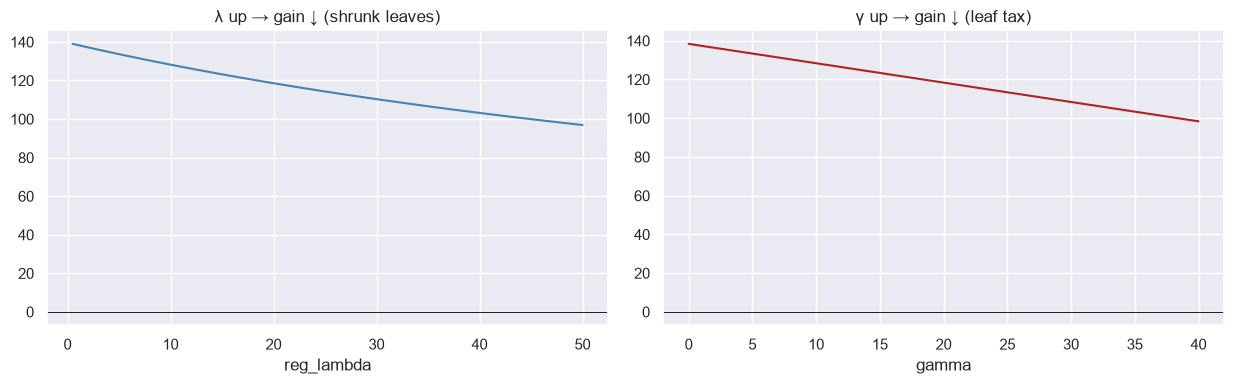

when gain < 0 the split is REJECTED — regularization in action


In [3]:
lams = np.linspace(0.5, 50, 60)
gains = [(GL**2/(HL+l) + GR**2/(HR+l)
          - (GL+GR)**2/(HL+HR+l)) for l in lams]

gammas = np.linspace(0, 40, 60)
gains_gamma = [(GL**2/(HL+1) + GR**2/(HR+1)
                - (GL+GR)**2/(HL+HR+1) - g) for g in gammas]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))
axes[0].plot(lams, gains, color="steelblue")
axes[0].axhline(0, c="k", lw=.7); axes[0].set_title(f"λ up → gain ↓ (shrunk leaves)")
axes[0].set_xlabel("reg_lambda")
axes[1].plot(gammas, gains_gamma, color="firebrick")
axes[1].axhline(0, c="k", lw=.7); axes[1].set_title("γ up → gain ↓ (leaf tax)")
axes[1].set_xlabel("gamma")
plt.tight_layout(); plt.show()
print("when gain < 0 the split is REJECTED - regularization in action")

## 3. Native NaN handling - route unknowns down a default side

In [4]:
demo = tips[["total_bill", "tip"]].copy()
demo.loc[demo.sample(frac=.15, random_state=1).index, "total_bill"] = np.nan

dtrain = xgb.DMatrix(demo[["total_bill"]], label=demo.tip,
                     missing=np.nan)                # explicit NaN handling
params = {"objective": "reg:squarederror", "max_depth": 2,
          "seed": 42}
bst = xgb.train(params, dtrain, num_boost_round=5)

# xgboost learned a DEFAULT DIRECTION for missing values at each split:
sap = bst.trees_to_dataframe()
# column names vary across xgboost versions -> find them case-insensitively
colmap = {c.lower(): c for c in sap.columns}
need = [colmap[k] for k in ("split", "yes", "no", "missing") if k in colmap]
if len(need) == 4:
    rows = sap[sap[colmap["missing"]].notna()]
    print(rows[need].head(4))
else:
    print("tree columns available:", list(sap.columns)[:8])
print("→ 'missing' column shows which branch NaNs travel down - learned, not imputed!")

       Split  Yes   No Missing
0  17.920000  0-1  0-2     0-2
1  13.160000  0-3  0-4     0-4
2  24.709999  0-5  0-6     0-5
7  16.580000  1-1  1-2     1-2
→ 'missing' column shows which branch NaNs travel down — learned, not imputed!


## Summary & key takeaways

- Split gain uses gradient+hessian sums with λ-shrinkage and a γ leaf-tax.
- Positive gain ⇔ keep the split; penalties make XGB conservative by design.
- NaNs are first-class: each split learns a default direction.
- Everything else (additive rounds, ν-shrinkage) matches plain GBM.